In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import os

if os.getcwd().split("/")[-1] == "notebooks":
    os.chdir("../")


In [2]:
import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import ssm
from scipy import stats
from pathlib import Path
import pickle
import copy
import warnings
warnings.filterwarnings('ignore')

from notebooks.imports import *
from config import dir_config
from src.utils.glm_hmm_utils import global_fit
from src.utils.glm_hmm_utils_cv import session_wise_fit_cv

## Configuration

Loads the feature config saved by notebook 4.10.

In [3]:
processed_dir = Path(dir_config.data.processed)
glm_hmm_dir = Path(processed_dir, 'glm_hmm_models')

# MODEL_NAME = 'prior_model_color_1back'
MODEL_NAME = "prior_model_NoColor_1back"
with open(Path(glm_hmm_dir, f'{MODEL_NAME}_config.pkl'), 'rb') as f:
    feature_config = pickle.load(f)

CURRENT_TRIAL_FEATURES = feature_config['current_trial_features']
PREV_TRIAL_FEATURES    = feature_config['prev_trial_features']
N_TRIALS_BACK          = feature_config['n_trials_back']
MODEL_FEATURES         = feature_config['model_features']
INPUT_DIM              = feature_config['input_dim']
hc_session_ids         = feature_config['session_ids']['hc']

print('Model features:', MODEL_FEATURES)
print('Input dim:', INPUT_DIM)
print('HC sessions:', hc_session_ids)

# Key interpretation:
# weight on `color`  → prior integration strength (high = biases toward most frequent direction)
# weight on `normalized_stimulus` → perceptual sensitivity
# weight on `bias`   → global response bias

Model features: ['normalized_stimulus', 'bias', 'prev_choice_1', 'prev_coherence_1', 'prev_choice_coherence_1']
Input dim: 5
HC sessions: ['AV', 'BC', 'BF', 'EM', 'ES', 'GF', 'GP', 'HC1', 'HC12', 'HC13', 'HC3', 'HC6', 'HC7', 'HC8', 'HC9', 'JA', 'MRM', 'SY']


## Load HC Data

In [4]:
data_all = pd.read_csv(Path(glm_hmm_dir, f'{MODEL_NAME}_data.csv'))
data_all.choice  = data_all.choice.fillna(-1).astype(int)
data_all.outcome = data_all.outcome.fillna(-1).astype(int)

# Filter to HC sessions only
data = data_all[data_all['session_id'].isin(hc_session_ids)].copy().reset_index(drop=True)
print('HC data shape:', data.shape)
print('Sessions found:', sorted(data['session_id'].unique()))

HC data shape: (11267, 16)
Sessions found: ['AV', 'BC', 'BF', 'EM', 'ES', 'GF', 'GP', 'HC1', 'HC12', 'HC13', 'HC3', 'HC6', 'HC7', 'HC8', 'HC9', 'JA', 'MRM', 'SY']


## Design Matrix Construction

For each session, builds:
- Observations: binary choices (n_trials, 1)
- Inputs: design matrix (n_trials, INPUT_DIM)
- Masks: valid trial indicator (n_trials, 1)

Continuous features use a **fixed, zero-preserving scale** (`signed_coherence / 100`, identical
across all sessions); `prev_choice` is coded ±1. Features are **not** z-scored per session —
mean-centering would shift physical coherence=0 off zero (folding the prior-induced sampling
skew into the bias term) and per-session std scaling would break weight comparability across
sessions and groups.

In [5]:
def extract_previous_trial_data(session_data, valid_idx, first_trial):
    n_trials = session_data.shape[0] - first_trial
    prev_data = {}
    signed_coherence = session_data.signed_coherence.values / 100
    choice = session_data.choice.values * 2 - 1  # recode to -1/+1

    for var in PREV_TRIAL_FEATURES:
        prev_data[var] = np.empty((n_trials, N_TRIALS_BACK))

    for i in range(first_trial, session_data.shape[0]):
        valid_before = valid_idx[valid_idx < i][-N_TRIALS_BACK:]
        padded = np.pad(valid_before, (N_TRIALS_BACK - len(valid_before), 0),
                        'constant', constant_values=0)
        for var in PREV_TRIAL_FEATURES:
            var_col = var[5:] if var.startswith('prev_') else var
            if var_col == 'coherence':
                vals = signed_coherence
            elif var_col == 'choice_coherence':
                vals = choice * signed_coherence
            elif var_col == 'choice':
                vals = choice  # use ±1 recode (symmetric, zero-centered)
            else:
                vals = session_data[var_col].values
            prev_data[var][i - first_trial] = vals[padded]
    return prev_data


def prepare_input_data(session_data, valid_idx, first_trial):
    n_trials = session_data.shape[0] - first_trial
    X = np.ones((1, n_trials, INPUT_DIM))
    for idx, feat in enumerate(CURRENT_TRIAL_FEATURES):
        if feat == 'normalized_stimulus':
            X[0, :, idx] = session_data.signed_coherence.values[first_trial:] / 100
        elif feat == 'bias':
            X[0, :, idx] = 1.0
        else:
            # color, prior_strength — already in dataframe
            X[0, :, idx] = session_data[feat].values[first_trial:]
    prev_data = extract_previous_trial_data(session_data, valid_idx, first_trial)
    col_idx = len(CURRENT_TRIAL_FEATURES)
    for var in PREV_TRIAL_FEATURES:
        for n in range(N_TRIALS_BACK):
            X[0, :, col_idx] = prev_data[var][:, n]
            col_idx += 1
    return list(X)


def process_sessions(data, session_ids, seed=42):
    npr.seed(seed)
    inputs_list, choices_list, masks_list, rt_list, color_list = [], [], [], [], []

    for session_id in session_ids:
        sess = data[data['session_id'] == session_id].reset_index(drop=True)
        valid_idx = np.where(sess.outcome >= 0)[0]
        if len(valid_idx) < N_TRIALS_BACK + 1:
            print(f'  WARNING: {session_id} has too few valid trials, skipping.')
            continue
        first_trial = valid_idx[N_TRIALS_BACK - 1] + 1

        inputs = prepare_input_data(sess, valid_idx, first_trial)
        choices = sess.choice.values[first_trial:].astype(int)
        invalid_idx = np.where(sess.outcome.values[first_trial:] < 0)[0]
        if invalid_idx.size > 0:
            choices[invalid_idx] = np.random.choice([0, 1], size=invalid_idx.size)

        mask = np.ones_like(choices, dtype=bool)
        mask[invalid_idx] = False

        inputs_list += inputs
        choices_list.append(choices.reshape(-1, 1))
        masks_list.append(mask.reshape(-1, 1))
        rt_list.append(sess.reaction_time.values[first_trial:].reshape(-1, 1))
        color_list.append(sess.color.values[first_trial:].reshape(-1, 1))

    unnorm_inputs = copy.deepcopy(inputs_list)

    return inputs_list, choices_list, masks_list, unnorm_inputs, rt_list, color_list

In [6]:
print('Building HC design matrices...')
inputs, choices, masks, unnorm_inputs, rts, colors = process_sessions(data, hc_session_ids)
# Track sessions that had enough trials
used_session_ids = [sid for sid in hc_session_ids
                    if len(data[data['session_id'] == sid]) > N_TRIALS_BACK + 5]
print(f'Processed {len(inputs)} sessions')
if inputs:
    print(f'Example session shape: inputs={inputs[0].shape}, choices={choices[0].shape}')

Building HC design matrices...
Processed 18 sessions
Example session shape: inputs=(678, 5), choices=(678, 1)


In [7]:
# convert input[0] to dataframe for easier visualization
input_df = pd.DataFrame(inputs[0], columns=MODEL_FEATURES)
input_df

,normalized_stimulus,bias,prev_choice_1,prev_coherence_1,prev_choice_coherence_1
0,1.00,1.0,1.0,1.00,1.00
1,-0.35,1.0,1.0,1.00,1.00
2,-0.13,1.0,1.0,-0.35,-0.35
3,0.35,1.0,1.0,-0.13,-0.13
4,0.13,1.0,-1.0,0.35,-0.35
5,0.35,1.0,1.0,0.13,0.13
6,0.13,1.0,1.0,0.35,0.35
7,0.13,1.0,1.0,0.13,0.13
8,-1.00,1.0,-1.0,0.13,-0.13
9,-1.00,1.0,-1.0,-1.00,1.00


## GLM-HMM Fitting: HC Validation

### Stage 1: Global fit (pooled HC)

Fit K = 1 to 4 states on all HC sessions combined. Uses 20 random initializations per K to avoid local optima.

In [8]:
STATE_RANGE = np.arange(1, 5)  # K = 1, 2, 3, 4
N_INITS = 20
N_ITERS_GLOBAL = 2500
N_ITERS_CV = 1000
K_FOLDS = 5
TOLERANCE = 1e-4

print(f'Fitting K = {STATE_RANGE} states | {N_INITS} inits | {N_ITERS_GLOBAL} EM iterations')
models_global, lls_global = global_fit(
    choices, inputs, masks,
    state_range=STATE_RANGE,
    n_initializations=N_INITS,
    n_iters=N_ITERS_GLOBAL,
    tolerance=TOLERANCE,
)
print('Global fit complete.')

Fitting K = [1 2 3 4] states | 20 inits | 2500 EM iterations
Fitting GLM globally...


  0%|          | 0/2500 [00:00<?, ?it/s]

Fitting 1 states...


Converged to LP: -5741.1:   0%|          | 2/2500 [00:00<01:57, 21.35it/s]


Fitting 2 states...


...

LP: -5867.0:   0%|          | 0/2500 [00:00<?, ?it/s]

Fitting 4 states...


LP: -5551.2:  94%|█████████▍| 2360/2500 [02:14<00:07, 18.84it/s]

Global fit complete.


Converged to LP: -5551.2:  94%|█████████▍| 2362/2500 [02:14<00:07, 17.55it/s]


In [9]:
# Select best initialization per K
init_params = {'glm_weights': {}, 'transition_matrices': {}}
for k in STATE_RANGE:
    best_idx = np.argmax([lls_global[k][i][-1] for i in range(N_INITS)])
    init_params['glm_weights'][k] = models_global[k][best_idx].observations.params
    init_params['transition_matrices'][k] = models_global[k][best_idx].transitions.params
    best_ll = lls_global[k][best_idx][-1]
    print(f'K={k}: best init={best_idx}, final LL={best_ll:.2f}')

K=1: best init=17, final LL=-5741.14
K=2: best init=7, final LL=-5600.13
K=3: best init=2, final LL=-5557.37
K=4: best init=13, final LL=-5551.15


### Stage 2: Session-wise 5-fold cross-validation

For each session and each K, fits on 4/5 of the trials and evaluates on the held-out 1/5. The test log-likelihood per trial is the primary model selection metric.

In [10]:
print(f'Running {K_FOLDS}-fold CV for {len(hc_session_ids)} sessions x {len(STATE_RANGE)} state models...')
models_cv, train_ll, test_ll = session_wise_fit_cv(
    choices, inputs, masks,
    n_sessions=len(choices),
    init_params=init_params,
    k_folds=K_FOLDS,
    state_range=STATE_RANGE,
    n_iters=N_ITERS_CV,
    tolerance=TOLERANCE,
)
print('Cross-validation complete.')
print(f'train_ll shape: {train_ll.shape}  (sessions x states x folds)')
print(f'test_ll shape:  {test_ll.shape}')

Running 5-fold CV for 18 sessions x 4 state models...
Fitting session 0...
Fitting 1 states...


Converged to LP: -280.1:   0%|          | 2/1000 [00:00<00:08, 122.17it/s]


Fitting 2 states...


Converged to LP: -306.8:   6%|▌         | 59/1000 [00:00<00:08, 115.06it/s]


Fitting 3 states...


...

LP: -394.3:   1%|          | 7/1000 [00:00<00:15, 63.52it/s]

Fitting 4 states...


LP: -376.1:   6%|▌         | 55/1000 [00:00<00:10, 90.08it/s]

Cross-validation complete.
train_ll shape: (18, 4, 5)  (sessions x states x folds)
test_ll shape:  (18, 4, 5)


Converged to LP: -376.0:   7%|▋         | 67/1000 [00:00<00:10, 85.06it/s]


In [11]:
# ---- Sanity check before model selection ----
print('=== Sanity checks ===')
print(f'Sessions processed: {len(choices)}')
print(f'Trial counts per session: {[len(c) for c in choices]}')

# K=1 weights — negate to get P(y=1) weights (SSM convention: params predict P(y=0))
k1_best = np.argmax([lls_global[1][i][-1] for i in range(N_INITS)])
w1 = -models_global[1][k1_best].observations.params.squeeze(1)[0]
print(f'\nK=1 GLM weights [P(y=1) convention, positive = toward most frequent direction]:')
for feat, wval in zip(MODEL_FEATURES, w1):
    flag = '  ← near zero! check data' if abs(wval) < 0.05 and feat != 'bias' else ''
    print(f'  {feat:<30}: {wval:+.4f}{flag}')

print(f'\nExpected: normalized_stimulus > 0  (coherence drives choice toward prior direction)')
print(f'          color              > 0  (prior cue biases toward most frequent direction)')
print(f'\nlog(0.5) = {np.log(0.5):.4f}  ← if test LL/trial is near this, model predicts at chance')

=== Sanity checks ===
Sessions processed: 18
Trial counts per session: [678, 632, 616, 654, 664, 619, 599, 590, 583, 630, 620, 601, 601, 635, 639, 622, 625, 641]

K=1 GLM weights [P(y=1) convention, positive = toward most frequent direction]:
  normalized_stimulus           : +3.2405
  bias                          : +0.1584
  prev_choice_1                 : +0.1948
  prev_coherence_1              : +0.0925
  prev_choice_coherence_1       : -0.0743

Expected: normalized_stimulus > 0  (coherence drives choice toward prior direction)
          color              > 0  (prior cue biases toward most frequent direction)

log(0.5) = -0.6931  ← if test LL/trial is near this, model predicts at chance


## Model Selection

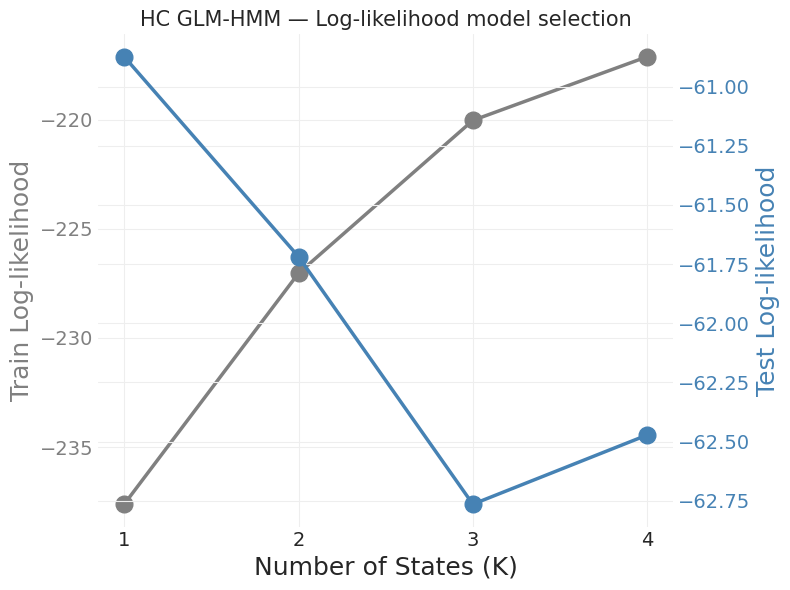

Best K by test LL: K = 1

K        Train LL      Test LL
1         -237.62       -60.87
2         -227.04       -61.72
3         -220.04       -62.76
4         -217.12       -62.47


In [12]:
# ---- Log-likelihood model selection (twin y-axes, matching 2.31 convention) ----
# train_ll and test_ll are TOTAL LLs per session-fold pair — different scales by design
# (train = 4x more data than test). Use twin axes so both curves are readable.
test_ll_mean  = np.nanmean(test_ll,  axis=(0, 2))   # (n_states,)
train_ll_mean = np.nanmean(train_ll, axis=(0, 2))

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(STATE_RANGE, train_ll_mean, marker='o', markersize=12, linewidth=2.5,
         color='grey', label='Train LL')
ax1.set_xlabel('Number of States (K)', fontsize=18)
ax1.set_ylabel('Train Log-likelihood', fontsize=18, color='grey')
ax1.tick_params(axis='y', labelcolor='grey', labelsize=14)
ax1.tick_params(axis='x', labelsize=14)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = ax1.twinx()
ax2.plot(STATE_RANGE, test_ll_mean, marker='o', markersize=12, linewidth=2.5,
         color='steelblue', label='Test LL')
ax2.set_ylabel('Test Log-likelihood', fontsize=18, color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue', labelsize=14)
ax2.spines['top'].set_visible(False)

ax1.set_xticks(STATE_RANGE)
plt.title('HC GLM-HMM — Log-likelihood model selection', fontsize=15)
plt.tight_layout()
plt.savefig(Path(glm_hmm_dir, f'{MODEL_NAME}_hc_model_selection_ll.pdf'), bbox_inches='tight')
plt.show()

best_k_ll = STATE_RANGE[np.argmax(test_ll_mean)]
print(f'Best K by test LL: K = {best_k_ll}')
print(f'\n{"K":<4} {"Train LL":>12} {"Test LL":>12}')
for k, tr, te in zip(STATE_RANGE, train_ll_mean, test_ll_mean):
    print(f'{k:<4} {tr:>12.2f} {te:>12.2f}')

In [13]:
best_k_ll = 2


In [14]:
SELECTED_K = best_k_ll
print(f'Selected K = {SELECTED_K}  (by test log-likelihood)')

Selected K = 2  (by test log-likelihood)


## State Interpretation\n\nExtract GLM weights and transition matrix from the best global model at `SELECTED_K`.\n\n**Weight interpretation (data is direction-normalised: 1 = toward most frequent direction):**\n- `normalized_stimulus`: perceptual sensitivity — how strongly sensory evidence drives choice toward the prior direction\n- `color`: **prior integration** — additional bias toward most frequent direction when the unequal-prior cue appears; the primary measure of Bayesian prior use\n- `bias`: overall response bias (independent of stimulus or prior)\n- `prev_choice_1`, `prev_coherence_1`, `prev_choice_coherence_1`: trial history effects\n\n**State labeling:** sort by `color` weight (descending) → State 1 = most prior-engaged ("Bayesian"), last state = least prior-engaged.

In [15]:
best_model = models_global[SELECTED_K][np.argmax([lls_global[SELECTED_K][i][-1] for i in range(N_INITS)])]

# SSM stores params for P(y=0|state,x) — negate to get weights for P(y=1|state,x).
# After negation: positive weight = increases P(choice=1 = toward most frequent direction).
# This matches the sign convention in predictive_accuracy() which also uses -params.
weights   = -best_model.observations.params.squeeze(1)  # (K, INPUT_DIM)
trans_mat =  best_model.transitions.params[0]            # (K, K)

# Sort states by the prior-integration regressor (descending) → State 1 = most prior-engaged.
# Use 'color' if the model includes it, otherwise 'bias' — which, because direction is
# pre-normalized so choice=1 = toward the prior, is itself the directional-prior readout.
order_feat  = 'color' if 'color' in MODEL_FEATURES else 'bias'
order_col   = MODEL_FEATURES.index(order_feat)
state_order = np.argsort(weights[:, order_col])[::-1]
weights     = weights[state_order]
trans_mat   = trans_mat[np.ix_(state_order, state_order)]

print('GLM weights per state (negated: positive = biases toward most frequent direction):')
df_weights = pd.DataFrame(weights, columns=MODEL_FEATURES,
                           index=[f'State {i+1}' for i in range(SELECTED_K)])
print(df_weights.round(3).to_string())
print()
print('Transition matrix (row=from, col=to):')
df_trans = pd.DataFrame(trans_mat,
                         index=[f'State {i+1}' for i in range(SELECTED_K)],
                         columns=[f'State {i+1}' for i in range(SELECTED_K)])
print(df_trans.round(3).to_string())

GLM weights per state (negated: positive = biases toward most frequent direction):
         normalized_stimulus   bias  prev_choice_1  prev_coherence_1  prev_choice_coherence_1
State 1                5.209  0.309          0.206             0.055                   -0.243
State 2                1.664 -0.024          0.195             0.207                   -0.019

Transition matrix (row=from, col=to):
         State 1  State 2
State 1   -0.004   -5.592
State 2   -4.780   -0.008


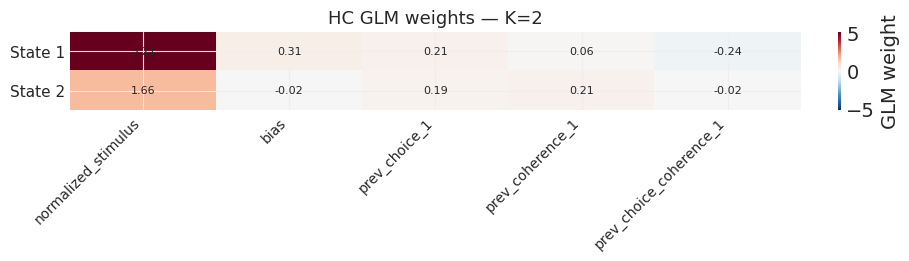

In [16]:
fig, ax = plt.subplots(figsize=(9, max(2.5, SELECTED_K * 0.8)), constrained_layout=True)
im = ax.imshow(weights, aspect='auto', cmap='RdBu_r',
               vmin=-np.abs(weights).max(), vmax=np.abs(weights).max())
fig.colorbar(im, ax=ax, label='GLM weight')
ax.set_xticks(range(INPUT_DIM))
ax.set_xticklabels(MODEL_FEATURES, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(SELECTED_K))
ax.set_yticklabels([f'State {i+1}' for i in range(SELECTED_K)], fontsize=11)
ax.set_title(f'HC GLM weights — K={SELECTED_K}', fontsize=13)
for i in range(SELECTED_K):
    for j in range(INPUT_DIM):
        ax.text(j, i, f'{weights[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.savefig(Path(glm_hmm_dir, f'{MODEL_NAME}_hc_weights_K{SELECTED_K}.pdf'), bbox_inches='tight')
plt.show()

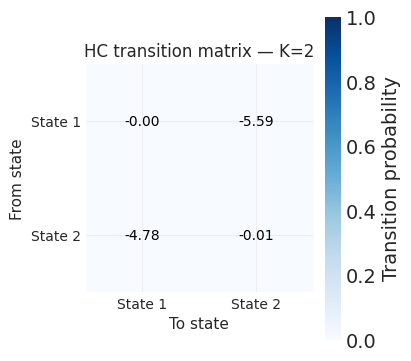

In [17]:
fig, ax = plt.subplots(figsize=(4, 3.5), constrained_layout=True)
im = ax.imshow(trans_mat, vmin=0, vmax=1, cmap='Blues')
fig.colorbar(im, ax=ax, label='Transition probability')
ax.set_xticks(range(SELECTED_K))
ax.set_xticklabels([f'State {i+1}' for i in range(SELECTED_K)], fontsize=10)
ax.set_yticks(range(SELECTED_K))
ax.set_yticklabels([f'State {i+1}' for i in range(SELECTED_K)], fontsize=10)
ax.set_xlabel('To state', fontsize=11)
ax.set_ylabel('From state', fontsize=11)
ax.set_title(f'HC transition matrix — K={SELECTED_K}', fontsize=12)
for i in range(SELECTED_K):
    for j in range(SELECTED_K):
        ax.text(j, i, f'{trans_mat[i, j]:.2f}', ha='center', va='center', fontsize=10,
                color='white' if trans_mat[i, j] > 0.6 else 'black')
plt.savefig(Path(glm_hmm_dir, f'{MODEL_NAME}_hc_transition_K{SELECTED_K}.pdf'), bbox_inches='tight')
plt.show()

## State Occupancy and Posterior Inference

In [18]:
state_posteriors_hc = []
viterbi_states_hc   = []

for idx_sess in range(len(choices)):
    posterior = best_model.expected_states(
        choices[idx_sess], input=inputs[idx_sess], mask=masks[idx_sess]
    )[0][:, state_order]
    state_posteriors_hc.append(posterior)

    vit_raw = best_model.most_likely_states(
        choices[idx_sess], input=inputs[idx_sess], mask=masks[idx_sess]
    )
    remap = {old: new for new, old in enumerate(state_order)}
    viterbi_states_hc.append(np.array([remap[s] for s in vit_raw]))

occupancy_hc = np.array([[np.mean(vit == k) for k in range(SELECTED_K)]
                          for vit in viterbi_states_hc])
print('HC state occupancy fractions (mean across sessions):')
for k in range(SELECTED_K):
    print(f'  State {k+1}: {occupancy_hc[:, k].mean():.3f} ± {occupancy_hc[:, k].std(ddof=1):.3f}')

HC state occupancy fractions (mean across sessions):
  State 1: 0.711 ± 0.345
  State 2: 0.289 ± 0.345


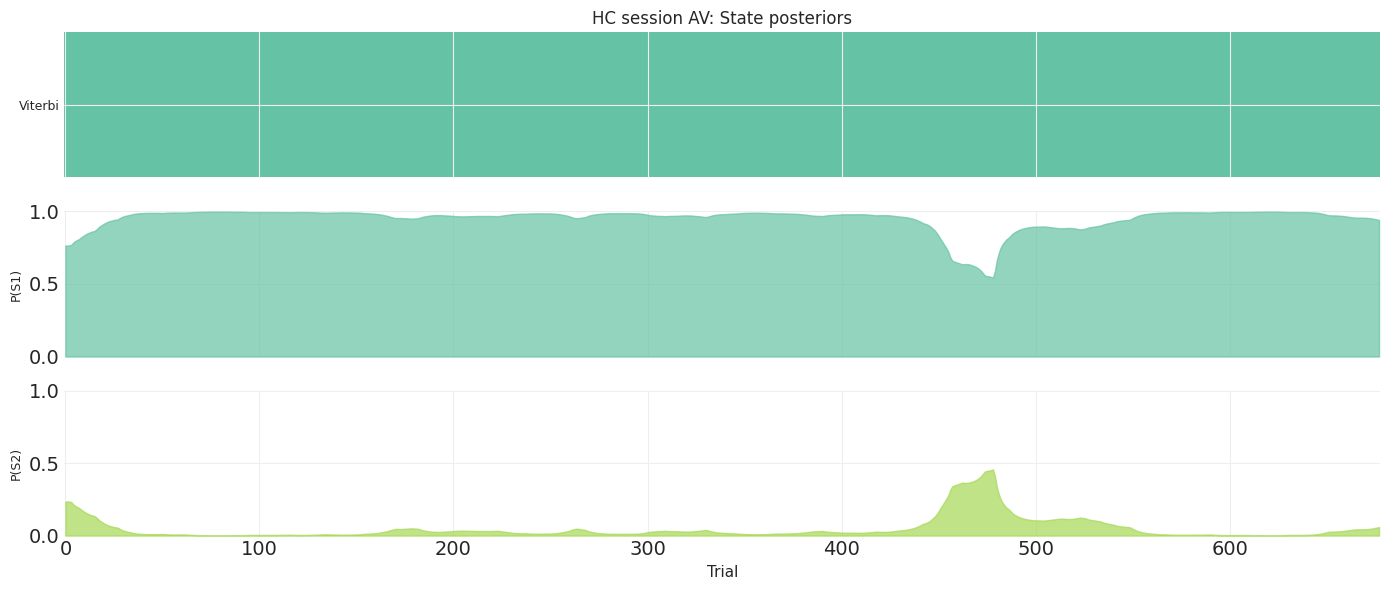

In [19]:
# Plot example session: trial-level state posteriors
example_sess = 0
T = len(viterbi_states_hc[example_sess])
colors_states = plt.cm.Set2(np.linspace(0, 0.6, SELECTED_K))

fig, axes = plt.subplots(SELECTED_K + 1, 1, figsize=(14, 3 + SELECTED_K * 1.5), sharex=True)

# Top: Viterbi state sequence
axes[0].imshow(viterbi_states_hc[example_sess].reshape(1, -1), aspect='auto',
               cmap=plt.cm.Set2, vmin=0, vmax=SELECTED_K - 1, interpolation='none')
axes[0].set_yticks([0])
axes[0].set_yticklabels(['Viterbi'], fontsize=9)
axes[0].set_title(f'HC session {hc_session_ids[example_sess]}: State posteriors', fontsize=12)

# Lower: posterior probability per state
for k in range(SELECTED_K):
    axes[k + 1].fill_between(range(T), state_posteriors_hc[example_sess][:, k],
                              color=colors_states[k], alpha=0.7)
    axes[k + 1].set_ylabel(f'P(S{k+1})', fontsize=9)
    axes[k + 1].set_ylim(0, 1)
    axes[k + 1].set_yticks([0, 0.5, 1])
    for spine in ['top', 'right']:
        axes[k + 1].spines[spine].set_visible(False)

axes[-1].set_xlabel('Trial', fontsize=11)
plt.tight_layout()
plt.savefig(Path(glm_hmm_dir, f'{MODEL_NAME}_hc_example_session_posteriors.pdf'), bbox_inches='tight')
plt.show()

## State-specific Psychometric Curves

For each hidden state, plot p(right) vs signed coherence separately for unequal prior (color=1) and equal prior (color=0) trials.

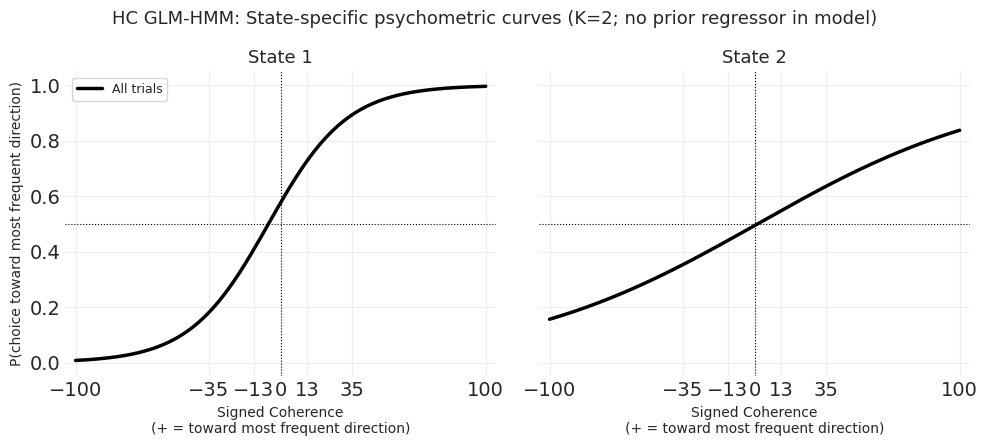

In [20]:
from scipy.special import expit

x_norm = np.linspace(-1, 1, 200)
stim_idx = MODEL_FEATURES.index('normalized_stimulus')
bias_idx = MODEL_FEATURES.index('bias')

# Data-driven condition split: use whichever prior-condition regressor the loaded
# model includes. Each condition sets that one feature; all other non-stimulus,
# non-bias features (trial history, etc.) are held at 0 (neutral reference), and
# bias is always included. This adapts automatically across model variants
# (color / prior_strength / NoColor).
if 'color' in MODEL_FEATURES:
    cond_feat  = 'color'
    conditions = [('Unequal prior (color=1)', 1.0, '-',  'black'),
                  ('Equal prior (color=0)',   0.0, '--', 'gray')]
elif 'prior_strength' in MODEL_FEATURES:
    cond_feat  = 'prior_strength'
    conditions = [('Prior toward (+1)',  1.0, '-',  'black'),
                  ('No prior (0)',        0.0, '--', 'gray'),
                  ('Prior against (-1)', -1.0, ':',  'darkred')]
else:
    cond_feat  = None
    conditions = [('All trials', None, '-', 'black')]

def state_logit(w, x, cond_val):
    """logit for P(choice=1): stimulus varied over x, bias on, the condition
    feature (if any) set to cond_val, all other features at 0 (neutral)."""
    logit = w[bias_idx] + w[stim_idx] * x
    if cond_feat is not None and cond_val is not None:
        logit = logit + w[MODEL_FEATURES.index(cond_feat)] * cond_val
    return logit

fig, axes = plt.subplots(1, SELECTED_K, figsize=(5 * SELECTED_K, 4.5), sharey=True)
if SELECTED_K == 1:
    axes = [axes]

for k in range(SELECTED_K):
    ax = axes[k]
    w  = weights[k]

    for cond_label, cond_val, ls, c in conditions:
        p_right = expit(state_logit(w, x_norm, cond_val))
        ax.plot(x_norm * 100, p_right, ls=ls, color=c, lw=2.5, label=cond_label)

    ax.axhline(0.5, color='k', lw=0.8, ls=':')
    ax.axvline(0,   color='k', lw=0.8, ls=':')
    ax.set_xlim(-105, 105)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks([-100, -35, -13, 0, 13, 35, 100])
    ax.set_xlabel('Signed Coherence\n(+ = toward most frequent direction)', fontsize=10)
    if k == 0:
        ax.set_ylabel('P(choice toward most frequent direction)', fontsize=10)
        ax.legend(fontsize=9)
    ax.set_title(f'State {k+1}', fontsize=13)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

cond_note = f'split by {cond_feat}' if cond_feat else 'no prior regressor in model'
fig.suptitle(f'HC GLM-HMM: State-specific psychometric curves (K={SELECTED_K}; {cond_note})', fontsize=13)
plt.tight_layout()
plt.savefig(Path(glm_hmm_dir, f'{MODEL_NAME}_hc_psychometric_curves_K{SELECTED_K}.pdf'), bbox_inches='tight')
plt.show()

## Save HC Models

In [ ]:
# Build session data dict
session_data_hc = {}
for idx, sid in enumerate(used_session_ids):
    if idx >= len(inputs):
        continue
    df = {
        'choices': choices[idx].ravel(),
        'stimulus': unnorm_inputs[idx][:, MODEL_FEATURES.index('normalized_stimulus')],
        'color': colors[idx].ravel(),
        'mask': masks[idx].ravel(),
    }
    for i, feat in enumerate(MODEL_FEATURES):
        df[feat] = inputs[idx][:, i]
    session_data_hc[sid] = pd.DataFrame(df)

hc_model_dict = {
    'group': 'HC',
    'used_session_ids': used_session_ids,
    'config': feature_config,
    'selected_k': SELECTED_K,
    'state_order': state_order.tolist(),
    'global': {
        'models': models_global,
        'lls': lls_global,
        'init_params': init_params,
        'best_model_weights': weights,
        'best_model_transition': trans_mat,
    },
    'cv': {
        'models': models_cv,
        'train_ll': train_ll,    # (n_sessions, n_states, k_folds)
        'test_ll': test_ll,
        'mean_test_ll': test_ll_mean,
        'state_range': STATE_RANGE.tolist(),
    },
    'posteriors': {
        'smoothed': state_posteriors_hc,
        'viterbi': viterbi_states_hc,
        'occupancy': occupancy_hc,
    },
    'data': session_data_hc,
}

In [ ]:
# out_path = Path(glm_hmm_dir, f"{MODEL_NAME}_hc.pkl")
# with open(out_path, "wb") as f:
#     pickle.dump(hc_model_dict, f)
# print(f"Saved HC model dict to: {out_path}")
# print(f"Selected K={SELECTED_K} — use this as candidate K; final K determined by cross-group comparison in 4.40.")